# Author: Dr Partha Majumdar
## ORC-ID: 0009-0002-7375-8034

In [1]:
import torch

# Step 1: Define the sentence

In [2]:
sentence = "Children are playing games outside"
words = sentence.lower().split()

print("Words in sentence:")
print(words)

Words in sentence:
['children', 'are', 'playing', 'games', 'outside']


# Step 2: Build the vocabulary

In [3]:
vocab = sorted(set(words))
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for word, idx in word_to_index.items()}

print("Word to Index Mapping:")
for word, idx in word_to_index.items():
    print(f"{word} -> {idx}")

Word to Index Mapping:
are -> 0
children -> 1
games -> 2
outside -> 3
playing -> 4


# Step 3: Define the subword extraction function

In [4]:
def extract_subwords(word, min_n=3, max_n=3):
    word = f"<{word}>"
    subwords = []

    for n in range(min_n, max_n + 1):
        for i in range(len(word) - n + 1):
            subwords.append(word[i:i+n])

    return subwords

# Step 4: Extract subwords for every unique word

In [5]:
word_to_subwords = {}
for word in vocab:
    word_to_subwords[word] = extract_subwords(word)

print("Subwords of each word:")
for word, subwords in word_to_subwords.items():
    print(f"{word} -> {subwords}")

Subwords of each word:
are -> ['<ar', 'are', 're>']
children -> ['<ch', 'chi', 'hil', 'ild', 'ldr', 'dre', 'ren', 'en>']
games -> ['<ga', 'gam', 'ame', 'mes', 'es>']
outside -> ['<ou', 'out', 'uts', 'tsi', 'sid', 'ide', 'de>']
playing -> ['<pl', 'pla', 'lay', 'ayi', 'yin', 'ing', 'ng>']


# Step 5: Build the complete subword vocabulary

In [6]:
all_subwords = sorted(set(
    subword
    for word in vocab
    for subword in word_to_subwords[word]
))

subword_to_index = {subword: idx for idx, subword in enumerate(all_subwords)}
index_to_subword = {idx: subword for subword, idx in subword_to_index.items()}

print("Subword to Index Mapping:")
for subword, idx in subword_to_index.items():
    print(f"{subword} -> {idx}")

Subword to Index Mapping:
<ar -> 0
<ch -> 1
<ga -> 2
<ou -> 3
<pl -> 4
ame -> 5
are -> 6
ayi -> 7
chi -> 8
de> -> 9
dre -> 10
en> -> 11
es> -> 12
gam -> 13
hil -> 14
ide -> 15
ild -> 16
ing -> 17
lay -> 18
ldr -> 19
mes -> 20
ng> -> 21
out -> 22
pla -> 23
re> -> 24
ren -> 25
sid -> 26
tsi -> 27
uts -> 28
yin -> 29


# Step 6: Convert each word into its subword index tensor

In [7]:
word_to_subword_indices = {}
for word in vocab:
    word_to_subword_indices[word] = torch.tensor(
        [subword_to_index[subword] for subword in word_to_subwords[word]],
        dtype=torch.long
    )

print("Subword index tensors for each word:")
for word, tensor_indices in word_to_subword_indices.items():
    print(f"{word} -> {tensor_indices}")

Subword index tensors for each word:
are -> tensor([ 0,  6, 24])
children -> tensor([ 1,  8, 14, 16, 19, 10, 25, 11])
games -> tensor([ 2, 13,  5, 20, 12])
outside -> tensor([ 3, 22, 28, 27, 26, 15,  9])
playing -> tensor([ 4, 23, 18,  7, 29, 17, 21])


# Step 7: Generate the complete training dataset using a context window

In [8]:
window_size = 1
training_data = []

for target_position, target_word in enumerate(words):
    start = max(0, target_position - window_size)
    end = min(len(words), target_position + window_size + 1)

    for context_position in range(start, end):
        if context_position != target_position:
            context_word = words[context_position]
            training_data.append((target_word, context_word))

print("Complete Training Data (target, context) pairs:")
for pair in training_data:
    print(pair)

Complete Training Data (target, context) pairs:
('children', 'are')
('are', 'children')
('are', 'playing')
('playing', 'are')
('playing', 'games')
('games', 'playing')
('games', 'outside')
('outside', 'games')


# Step 7A: Add Negative Samples

In [9]:
import random

negative_samples = 2  # number of negatives per positive pair

training_data_with_labels = []

for target_word, context_word in training_data:

    # Positive example
    training_data_with_labels.append((target_word, context_word, 1))

    # Negative examples
    for _ in range(negative_samples):
        negative_word = random.choice(vocab)

        # Ensure it's not the actual context word
        while negative_word == context_word:
            negative_word = random.choice(vocab)

        training_data_with_labels.append((target_word, negative_word, 0))

# Step 8: Convert the training data to indexed form

In [10]:
indexed_training_data = []

for target_word, context_word, label in training_data_with_labels:

    target_subword_indices = word_to_subword_indices[target_word]
    context_word_index = torch.tensor(word_to_index[context_word], dtype=torch.long)
    label_tensor = torch.tensor(float(label))

    indexed_training_data.append((target_subword_indices, context_word_index, label_tensor))

print("Indexed Training Data:")
print("Indexed Training Data:")
for i, (target_sub_idx, context_idx, label) in enumerate(indexed_training_data):
    print(f"Example {i+1}:")
    print("Target subword indices:", target_sub_idx)
    print("Context word index    :", context_idx.item())
    print("Label                 :", int(label.item()))

Indexed Training Data:
Indexed Training Data:
Example 1:
Target subword indices: tensor([ 1,  8, 14, 16, 19, 10, 25, 11])
Context word index    : 0
Label                 : 1
Example 2:
Target subword indices: tensor([ 1,  8, 14, 16, 19, 10, 25, 11])
Context word index    : 1
Label                 : 0
Example 3:
Target subword indices: tensor([ 1,  8, 14, 16, 19, 10, 25, 11])
Context word index    : 4
Label                 : 0
Example 4:
Target subword indices: tensor([ 0,  6, 24])
Context word index    : 1
Label                 : 1
Example 5:
Target subword indices: tensor([ 0,  6, 24])
Context word index    : 2
Label                 : 0
Example 6:
Target subword indices: tensor([ 0,  6, 24])
Context word index    : 4
Label                 : 0
Example 7:
Target subword indices: tensor([ 0,  6, 24])
Context word index    : 4
Label                 : 1
Example 8:
Target subword indices: tensor([ 0,  6, 24])
Context word index    : 3
Label                 : 0
Example 9:
Target subword indi

# Step 9: Initialise trainable matrices

In [11]:
embedding_dim = 6

subword_embedding_matrix = torch.randn(
    len(subword_to_index), embedding_dim, requires_grad=True
)

output_embedding_matrix = torch.randn(
    len(vocab), embedding_dim, requires_grad=True
)

print("Subword Embedding Matrix Shape:", subword_embedding_matrix.shape)
print("Output Embedding Matrix Shape :", output_embedding_matrix.shape)

# Print Subword Embedding Matrix
print("\nSubword Embedding Matrix Z (|G| x d):")
for subword, idx in subword_to_index.items():
    vector = subword_embedding_matrix[idx].detach().numpy()
    print(f"{subword:>5} -> {vector}")

# Print Output Word Embedding Matrix
print("\nOutput Embedding Matrix U (|V| x d):")
for word, idx in word_to_index.items():
    vector = output_embedding_matrix[idx].detach().numpy()
    print(f"{word:>10} -> {vector}")

Subword Embedding Matrix Shape: torch.Size([30, 6])
Output Embedding Matrix Shape : torch.Size([5, 6])

Subword Embedding Matrix Z (|G| x d):
  <ar -> [-0.41740927 -0.9940965  -0.78336173 -0.6014254  -0.65976024  0.10433498]
  <ch -> [-0.71677166 -0.9511719   0.7670335   0.55706507 -1.5103915  -1.266077  ]
  <ga -> [ 0.36271152  0.49353412 -1.936198    1.5674088  -1.0567076   1.7003436 ]
  <ou -> [-0.5104459   0.18384835  0.12788673 -1.0464027  -0.7021691  -1.2206162 ]
  <pl -> [ 0.01680891  0.48001522  0.96241957 -0.24208735 -1.016306   -1.3626674 ]
  ame -> [-0.90206075  0.43568826 -2.009113    1.1372575   2.05495    -0.489604  ]
  are -> [ 0.69974077  0.03986671  0.04217704  1.4445559  -1.054918   -0.6492187 ]
  ayi -> [-1.2329324  -1.5487549   0.59822184 -0.04122175  0.75721073  0.12869893]
  chi -> [-0.5461875   0.74727535  1.3360101   0.76109785  0.35769874 -1.3932774 ]
  de> -> [ 1.1946964  0.648852   0.3527149 -0.3216583 -0.6214517  1.3720666]
  dre -> [ 0.04410542  0.5048361  

# Step 10: Training hyperparameters

In [12]:
learning_rate = 0.05
epochs = 500

# Step 11: Train over the complete dataset

Epoch 50 | Total Loss: 5.6250
Epoch 100 | Total Loss: 3.9343
Epoch 150 | Total Loss: 3.4522
Epoch 200 | Total Loss: 3.2695
Epoch 250 | Total Loss: 3.1818
Epoch 300 | Total Loss: 3.1327
Epoch 350 | Total Loss: 3.1021
Epoch 400 | Total Loss: 3.0816
Epoch 450 | Total Loss: 3.0671
Epoch 500 | Total Loss: 3.0562


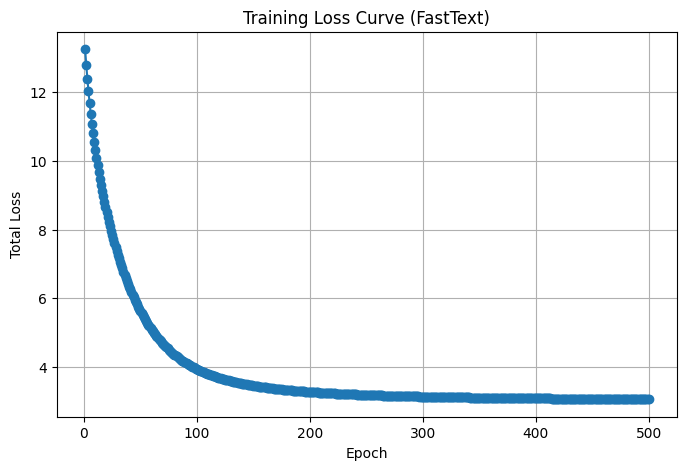

In [13]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Store loss values for plotting
# ---------------------------------------------------
loss_history = []

# ---------------------------------------------------
# Training loop
# ---------------------------------------------------
for epoch in range(epochs):
    total_loss = 0.0

    for target_subword_indices, context_word_index, label in indexed_training_data:

        # -------------------------------------------
        # Forward pass
        # -------------------------------------------
        target_subword_vectors = subword_embedding_matrix[target_subword_indices]
        target_word_vector = target_subword_vectors.mean(dim=0)

        context_word_vector = output_embedding_matrix[context_word_index]

        score = torch.dot(target_word_vector, context_word_vector)
        prediction = torch.sigmoid(score)

        # -------------------------------------------
        # Loss
        # -------------------------------------------
        loss = -(
            label * torch.log(prediction + 1e-9) +
            (1 - label) * torch.log(1 - prediction + 1e-9)
        )

        # -------------------------------------------
        # Backpropagation
        # -------------------------------------------
        loss.backward()

        # -------------------------------------------
        # Parameter update
        # -------------------------------------------
        with torch.no_grad():
            subword_embedding_matrix -= learning_rate * subword_embedding_matrix.grad
            output_embedding_matrix -= learning_rate * output_embedding_matrix.grad

        # -------------------------------------------
        # Clear gradients
        # -------------------------------------------
        subword_embedding_matrix.grad.zero_()
        output_embedding_matrix.grad.zero_()

        total_loss += loss.item()

    # Store loss for this epoch
    loss_history.append(total_loss)

    # Print only every 10th epoch
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1:2d} | Total Loss: {total_loss:.4f}")

# ---------------------------------------------------
# Plot Loss Curve
# ---------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss Curve (FastText)")
plt.grid(True)

plt.show()

# Step 12: Inspect trained example chosen randomly

In [14]:
import random

print("Inspecting 3 random examples after training:\n")

num_examples = 3
indices = random.sample(range(len(indexed_training_data)), num_examples)

for count, i in enumerate(indices):

    example_target_word, example_context_word = training_data[i % len(training_data)]
    example_target_subword_indices, example_context_word_index, example_label = indexed_training_data[i]

    example_target_subword_vectors = subword_embedding_matrix[example_target_subword_indices]
    example_target_word_vector = example_target_subword_vectors.mean(dim=0)
    example_context_word_vector = output_embedding_matrix[example_context_word_index]

    example_score = torch.dot(example_target_word_vector, example_context_word_vector)
    example_probability = torch.sigmoid(example_score)

    print(f"Example {count+1}:")
    print("Target word      :", example_target_word)
    print("Context word     :", example_context_word)
    print("Label            :", int(example_label.item()))
    print("Score            :", example_score.item())
    print("Probability      :", example_probability.item())
    print("-" * 50)

Inspecting 3 random examples after training:

Example 1:
Target word      : playing
Context word     : are
Label            : 0
Score            : -6.6680684089660645
Probability      : 0.0012692381860688329
--------------------------------------------------
Example 2:
Target word      : playing
Context word     : games
Label            : 1
Score            : 4.546201705932617
Probability      : 0.9895039796829224
--------------------------------------------------
Example 3:
Target word      : are
Context word     : children
Label            : 0
Score            : -4.943753242492676
Probability      : 0.007077350281178951
--------------------------------------------------
